In [1]:
# Make the project root importable so we can use the suspension package
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt

from suspension.hardpoints import example_frontend_hardpoints
from suspension.kinematics_front import solve_corner, compute_camber, wheel_travel

print("Imports OK")

Imports OK


## Front-view kinematic sweep

Using a representative (not measured) set of hardpoints, sweep the lower A-arm
through +/- 10 degrees and compute how the wheel moves.

The single most important curve in suspension geometry is **camber vs wheel travel**.
For a street/track car you want a gentle curve that gains negative camber in bump
(to keep the outside tire flat on the ground when the car rolls). The knobs that
control it are the A-arm lengths, the ratio of upper to lower arm length, and the
angles of the arms at static ride height.

In [2]:
hp = example_frontend_hardpoints()

print(f"Upright length:       {hp.upright_length()*1000:.1f} mm")
print(f"Static wheel center:  {hp.wheel_center}")
print(f"Static contact patch: {hp.contact_patch}")
print(f"Static kingpin axis:  {hp.static_kingpin_axis()}")

# Derived quantities worth knowing
print(f"\nUpper arm length (pivot center to ball joint):")
print(f"  {np.linalg.norm(hp.upper_ball_joint - hp.upper_pivot_center())*1000:.1f} mm")
print(f"Lower arm length (pivot center to ball joint):")
print(f"  {np.linalg.norm(hp.lower_ball_joint - hp.lower_pivot_center())*1000:.1f} mm")

# Kingpin inclination angle (static)
kp = hp.static_kingpin_axis()
# Angle from vertical, measured in the y-z plane (front view)
kpi_rad = np.arctan2(abs(kp[1]), kp[2])
print(f"\nStatic kingpin inclination (KPI): {np.rad2deg(kpi_rad):.2f} deg")

Upright length:       374.8 mm
Static wheel center:  [ 0.   -0.72  0.32]
Static contact patch: [ 0.   -0.72  0.  ]
Static kingpin axis:  [0.         0.16007116 0.98710548]

Upper arm length (pivot center to ball joint):
  371.2 mm
Lower arm length (pivot center to ball joint):
  480.4 mm

Static kingpin inclination (KPI): 9.21 deg


In [3]:
# Sweep the lower arm through +/- 10 degrees
angles_deg = np.linspace(-10, 10, 41)
angles_rad = np.deg2rad(angles_deg)

# Collect results into lists as we sweep
camber_list = []
travel_list = []
wc_list = []
cp_list = []
upper_bj_list = []
lower_bj_list = []

for angle in angles_rad:
    result = solve_corner(hp, angle)
    camber_list.append(compute_camber(result['wheel_center'], result['contact_patch']))
    travel_list.append(wheel_travel(hp, result) * 1000)  # convert to mm for readability
    wc_list.append(result['wheel_center'])
    cp_list.append(result['contact_patch'])
    upper_bj_list.append(result['upper_ball_joint'])
    lower_bj_list.append(result['lower_ball_joint'])

# Convert to numpy arrays for easy slicing/plotting
camber = np.array(camber_list)
travel = np.array(travel_list)
wc = np.array(wc_list)
cp = np.array(cp_list)
upper_bj = np.array(upper_bj_list)
lower_bj = np.array(lower_bj_list)

print(f"Wheel travel range:   {travel.min():.1f} to {travel.max():.1f} mm")
print(f"Camber range:         {camber.min():.2f} to {camber.max():.2f} deg")
print(f"Camber at static:     {camber[len(camber)//2]:.2f} deg")
print(f"Camber gain in bump:  {(camber[-1] - camber[len(camber)//2]) / (travel[-1] - travel[len(travel)//2]):.4f} deg/mm")

Wheel travel range:   -84.0 to 84.9 mm
Camber range:         -1.88 to 1.29 deg
Camber at static:     -0.00 deg
Camber gain in bump:  -0.0221 deg/mm


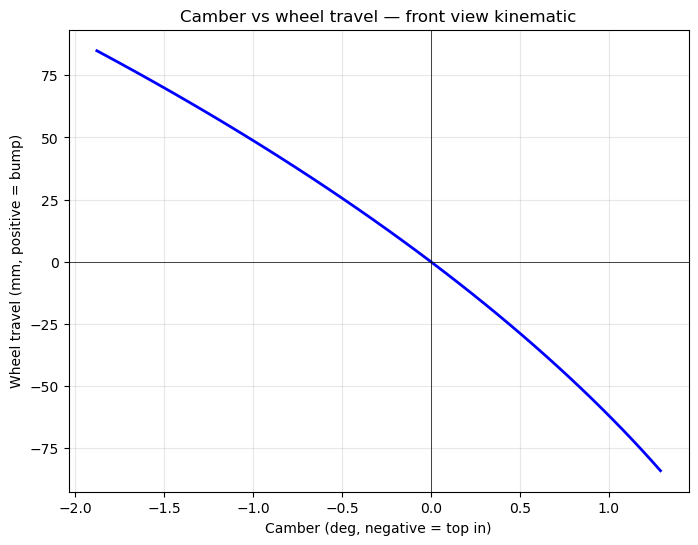

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(camber, travel, 'b-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Camber (deg, negative = top in)')
ax.set_ylabel('Wheel travel (mm, positive = bump)')
ax.set_title('Camber vs wheel travel — front view kinematic')
ax.grid(True, alpha=0.3)
plt.show()

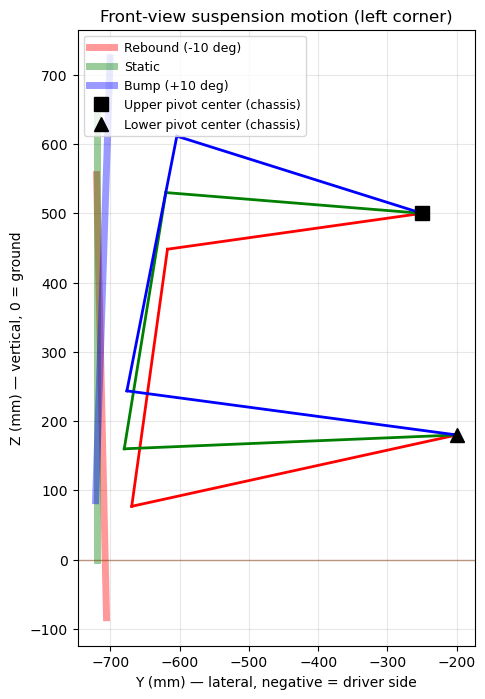

In [5]:
# Visualize the suspension at three positions: full rebound, static, full bump
fig, ax = plt.subplots(figsize=(10, 8))

def draw_corner(ax, hp, result, color, label):
    """Draw one snapshot of the suspension corner in the front (y-z) view."""
    upper_pc = hp.upper_pivot_center()
    lower_pc = hp.lower_pivot_center()

    # Upper A-arm: inboard pivot center to upper ball joint
    ax.plot([upper_pc[1]*1000, result['upper_ball_joint'][1]*1000],
            [upper_pc[2]*1000, result['upper_ball_joint'][2]*1000],
            color=color, linewidth=2)

    # Lower A-arm: inboard pivot center to lower ball joint
    ax.plot([lower_pc[1]*1000, result['lower_ball_joint'][1]*1000],
            [lower_pc[2]*1000, result['lower_ball_joint'][2]*1000],
            color=color, linewidth=2)

    # Upright: between the two ball joints
    ax.plot([result['lower_ball_joint'][1]*1000, result['upper_ball_joint'][1]*1000],
            [result['lower_ball_joint'][2]*1000, result['upper_ball_joint'][2]*1000],
            color=color, linewidth=2)

    # Wheel: drawn as a line from contact patch up through wheel center
    # (full height mirrored across wheel center to show the tire's vertical extent)
    wc = result['wheel_center']
    cp = result['contact_patch']
    tire_top = wc + (wc - cp)  # reflect contact patch across wheel center
    ax.plot([cp[1]*1000, tire_top[1]*1000],
            [cp[2]*1000, tire_top[2]*1000],
            color=color, linewidth=5, alpha=0.4, label=label)

# Three positions
positions = [(-np.deg2rad(10), 'red',   'Rebound (-10 deg)'),
             ( 0.0,             'green', 'Static'),
             ( np.deg2rad(10),  'blue',  'Bump (+10 deg)')]

for angle, color, label in positions:
    result = solve_corner(hp, angle)
    draw_corner(ax, hp, result, color, label)

# Mark the fixed inboard pivot centers (these don't move — they're on the chassis)
ax.plot(hp.upper_pivot_center()[1]*1000, hp.upper_pivot_center()[2]*1000,
        'ks', markersize=10, label='Upper pivot center (chassis)')
ax.plot(hp.lower_pivot_center()[1]*1000, hp.lower_pivot_center()[2]*1000,
        'k^', markersize=10, label='Lower pivot center (chassis)')

# Ground line
ax.axhline(0, color='saddlebrown', linewidth=1, alpha=0.5)

ax.set_xlabel('Y (mm) — lateral, negative = driver side')
ax.set_ylabel('Z (mm) — vertical, 0 = ground')
ax.set_title('Front-view suspension motion (left corner)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')  # critical — y and z must scale equally to see real geometry
plt.show()